<a href="https://colab.research.google.com/github/xcl-esc/Analise_Goodreads/blob/main/C%C3%B3digos/Analise_vari%C3%A1veis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/projeto_novo/Códigos/

/content/drive/MyDrive/projeto_novo/Códigos


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display_html
import matplotlib.ticker as ticker

In [ ]:
sns.set_theme(style="whitegrid")

df = pd.read_csv('/content/drive/MyDrive/projeto_novo/Dados/Dados_limpos/dados_limpos.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11121 entries, 0 to 11120
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11121 non-null  int64  
 1   title               11121 non-null  object 
 2   authors             11121 non-null  object 
 3   average_rating      11121 non-null  float64
 4   isbn                11121 non-null  object 
 5   isbn13              11121 non-null  int64  
 6   language_code       11121 non-null  object 
 7   num_pages           11121 non-null  int64  
 8   ratings_count       11121 non-null  int64  
 9   text_reviews_count  11121 non-null  int64  
 10  publication_date    11121 non-null  object 
 11  publisher           11121 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


Esta análise tem como objetivo encontrar os principais fatores que influenciam as avaliações de um livro.  
#Objetivos:
###- Quais fatores influenciam para um livro se tornar um sucesso?
###- O que os melhores livros tem em comum?
###- Que fatores podem influenciar um livro para ser considerado um fracasso?

Antes de responder qualquer pergunta, preciso entender como encontrar os livros que são relevantes para as buscas.

In [ ]:
df['ratings_count'].sort_values(ascending=True).unique()

array([      0,       1,       2, ..., 2457092, 2530894, 4597666])

In [ ]:
avaliacao = (df['average_rating'] > 4) & (df['ratings_count'] < 2)
df_av_min = df[avaliacao]
df_av_min.head(10)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
217,534,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.14,0060255080,9780060255084,eng,216,1,0,1989-01-01,HarperCollins
264,797,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,4.03,8408064762,9788408064763,spa,480,0,0,2006-05-01,Geoplaneta
481,1533,The Suppliant Maidens/The Persians/Seven again...,Aeschylus/E.D.A. Morshead,4.10,1419150014,9781419150012,eng,208,1,0,2004-06-17,Kessinger Publishing
624,2034,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,Aristophanes/F.W. Hall/W.M. Geldart,5.00,0198145047,9780198145042,grc,364,0,0,1922-02-22,Oxford University Press
786,2560,Willem de Kooning: Late Paintings,Julie Sylvester/David Sylvester,5.00,382960226X,9783829602266,eng,83,1,0,2006-09-01,Schirmer Mosel
2255,8077,Animales No Se Visten Los (Animals Should Def...,Judi Barrett/Ron Barrett,4.11,1595191356,9781595191359,eng,32,0,0,1991-10-30,Live Oak Media
2505,9153,The Barefoot Book Of Ballet Stories,Jane Yolen,4.21,1841482641,9781841482644,eng,96,1,0,2004-09-01,Barefoot Books
2956,10939,Ya Sé Que Te Quiero,Billy Crystal/Elizabeth Sayles,4.19,0060845988,9780060845988,spa,40,0,0,2006-04-11,Rayo
3006,11062,Roald Dahl: The Storyteller (Famous Lives),Jason Hook,4.06,0750244917,9780750244916,eng,48,0,0,2004-08-12,Hodder Wayland
3007,11069,Les Nouvelles Recettes irrésistibles de Roald ...,Roald Dahl/Quentin Blake,4.14,2070536289,9782070536283,fre,64,0,0,2002-09-18,Gallimard Jeunesse


In [ ]:
avaliacao = (df['average_rating'] < 5) & (df['ratings_count'] > 100)
df_av = df[avaliacao].sort_values(by=['average_rating'], ascending=False)
df_av.head(10)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
6587,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,0740748475,9780740748479,eng,1456,32213,930,2005-09-06,Andrews McMeel Publishing
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic
6589,24814,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,0836221362,9780836221367,eng,176,23875,303,1996-09-01,Andrews McMeel Publishing
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,0439827604,9780439827607,eng,3342,28242,808,2005-09-12,Scholastic
1848,6550,Early Color,Saul Leiter/Martin Harrison,4.73,3865211399,9783865211392,eng,156,144,8,2006-01-15,Steidl
6590,24816,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,0836217691,9780836217698,eng,176,15365,290,1994-09-06,Andrews McMeel Publishing
8929,34545,Elliott Erwitt: Snaps,Murray Sayle/Charles Flowers/Elliott Erwitt,4.72,071484330X,9780714843308,en-GB,544,102,6,2003-06-01,Phaidon Press
6593,24820,Calvin and Hobbes: Sunday Pages 1985-1995: An ...,Bill Watterson,4.71,0740721356,9780740721359,eng,96,3613,85,2001-09-17,Andrews McMeel Publishing
5614,20749,Study Bible: NIV,Anonymous,4.70,0310929555,9780310929550,eng,2198,4166,186,2002-10-01,Zondervan Publishing House
6497,24520,The Complete Aubrey/Maturin Novels (5 Volumes),Patrick O'Brian,4.70,039306011X,9780393060119,eng,6576,1338,81,2004-10-17,W. W. Norton & Company


##A tabela mostra que o ponto pivotal de classificação dos livros é o número de avaliações. Pois vemos casos onde o livro possui nota alta(acima de 4) e ainda assim 1 ou nenhuma avaliação. A tabela abaixo mostra a comparação entre os livros em relação ao número de avaliações.

In [ ]:
comparativo = (df.loc[[624, 786, 4, 6587]])
comparativo.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
624,2034,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,Aristophanes/F.W. Hall/W.M. Geldart,5.00,0198145047,9780198145042,grc,364,0,0,1922-02-22,Oxford University Press
786,2560,Willem de Kooning: Late Paintings,Julie Sylvester/David Sylvester,5.00,382960226X,9783829602266,eng,83,1,0,2006-09-01,Schirmer Mosel
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic
6587,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,0740748475,9780740748479,eng,1456,32213,930,2005-09-06,Andrews McMeel Publishing


Logo, o ponto de partida é o filtro dos livros baseado na quantidade de avaliações. Mas que número seria essa base para iniciar a observação das outras métricas?

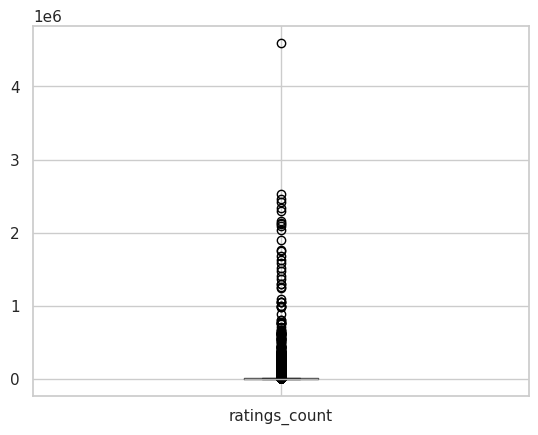

In [ ]:
df1 = df.copy()
df1.boxplot(column=['ratings_count'])
plt.show()

In [ ]:
df['ratings_count'].describe()

,ratings_count
count,1.112100e+04
mean,1.794512e+04
std,1.125091e+05
min,0.000000e+00
25%,1.040000e+02
50%,7.450000e+02
75%,4.996000e+03
max,4.597666e+06


In [ ]:
ava_format = df['ratings_count'].describe().to_frame()
ava_format['ratings_count'] = ava_format['ratings_count'].apply(lambda x: f"{x:,.2f}")
print(ava_format)

      ratings_count
count     11,121.00
mean      17,945.12
std      112,509.12
min            0.00
25%          104.00
50%          745.00
75%        4,996.00
max    4,597,666.00


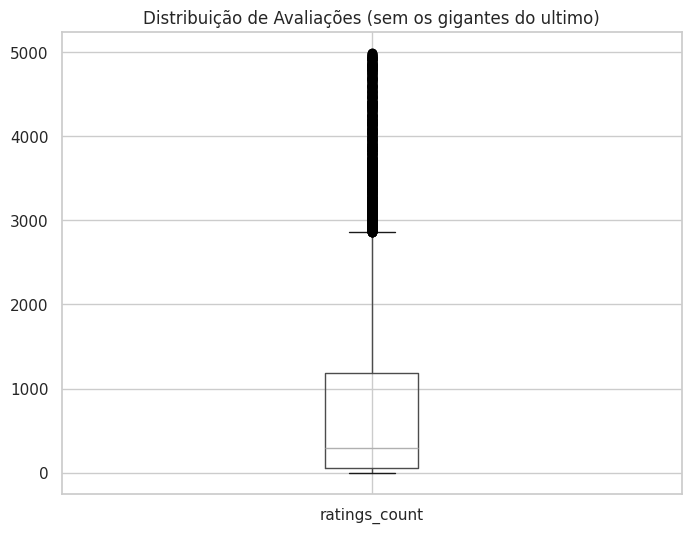

In [ ]:
df_menores = df[df['ratings_count'] < 5000]

plt.figure(figsize=(8, 6))
df_menores.boxplot(column=['ratings_count'])
plt.title('Distribuição de Avaliações (sem os gigantes do ultimo)')
plt.show()

###Vimos então que com um desvio padrão tão alto, utilizar a média ou a mediana diminuiria muito a quantidade de livros e abriria a possibilidade de perdermos informações ou contagens. Assim o número que dispõe uma maior parte do dataset seriam valores compreendidos acima do primeiro quartil (25%). Portanto, a primeira regra é observar livros com ao menos 100 avaliações.

In [ ]:
df_relevancia = df[df['ratings_count'] >= 100]

###Com isto definido, partimos para a primeira pergunta:
#- Quais fatores influenciam para um livro se tornar um sucesso entre os usuários do GoodReads?

A maior quantidade de avaliações ou a maior avaliação? O que define os melhores livros?

In [ ]:
df_relevancia.sort_values(by='ratings_count', ascending=False).head(15)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
10335,41865,Twilight (Twilight #1),Stephenie Meyer,3.59,0316015849,9780316015844,eng,501,4597666,94265,2006-09-06,Little Brown and Company
1697,5907,The Hobbit or There and Back Again,J.R.R. Tolkien,4.27,0618260307,9780618260300,eng,366,2530894,32871,2002-08-15,Houghton Mifflin
1462,5107,The Catcher in the Rye,J.D. Salinger,3.80,0316769177,9780316769174,eng,277,2457092,43499,2001-01-30,Back Bay Books
307,960,Angels & Demons (Robert Langdon #1),Dan Brown,3.89,1416524797,9781416524793,eng,736,2418736,21303,2006-04-01,Pocket
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,2004-05-01,Scholastic
4415,15881,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling/Mary GrandPré,4.42,0439064864,9780439064866,eng,341,2293963,34692,1999-06-02,Scholastic
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,2004-09-01,Scholastic
23,34,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,4.36,0618346252,9780618346257,eng,398,2128944,13670,2003-09-05,Houghton Mifflin Harcourt
2114,7613,Animal Farm,George Orwell/Boris Grabnar/Peter Škerl,3.93,0452284244,9780452284241,eng,122,2111750,29677,2003-05-06,NAL
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,2006-09-16,Scholastic


In [ ]:
df_relevancia.sort_values(by='average_rating', ascending=False).head(15)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
6587,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,0740748475,9780740748479,eng,1456,32213,930,2005-09-06,Andrews McMeel Publishing
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic
6589,24814,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,0836221362,9780836221367,eng,176,23875,303,1996-09-01,Andrews McMeel Publishing
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,0439827604,9780439827607,eng,3342,28242,808,2005-09-12,Scholastic
1848,6550,Early Color,Saul Leiter/Martin Harrison,4.73,3865211399,9783865211392,eng,156,144,8,2006-01-15,Steidl
8929,34545,Elliott Erwitt: Snaps,Murray Sayle/Charles Flowers/Elliott Erwitt,4.72,071484330X,9780714843308,en-GB,544,102,6,2003-06-01,Phaidon Press
6590,24816,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,0836217691,9780836217698,eng,176,15365,290,1994-09-06,Andrews McMeel Publishing
6593,24820,Calvin and Hobbes: Sunday Pages 1985-1995: An ...,Bill Watterson,4.71,0740721356,9780740721359,eng,96,3613,85,2001-09-17,Andrews McMeel Publishing
10936,44826,The Price of the Ticket: Collected Nonfiction ...,James Baldwin,4.70,0312643063,9780312643065,eng,712,404,30,1985-09-15,St. Martin's Press
6497,24520,The Complete Aubrey/Maturin Novels (5 Volumes),Patrick O'Brian,4.70,039306011X,9780393060119,eng,6576,1338,81,2004-10-17,W. W. Norton & Company


Ter uma quantidade de avaliações muito alta, as vezes pode mascarar outros filtros, se considerarmos que mais de 4 milhões de avaliações é quase impossível manter uma nota acima de 4.5.

Então vamos observar primeiro os livros do último quartil, ou seja, avaliações acima de 4 996.

In [ ]:
nota_e_avaliacao = (df['average_rating'] > 4) & (df['ratings_count'] > 4996)
df_av_nota = df[nota_e_avaliacao].sort_values(by=['average_rating', 'ratings_count'], ascending=[False, False])
df_av_nota.head(40)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
6587,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,0740748475,9780740748479,eng,1456,32213,930,2005-09-06,Andrews McMeel Publishing
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic
6589,24814,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,0836221362,9780836221367,eng,176,23875,303,1996-09-01,Andrews McMeel Publishing
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,0439827604,9780439827607,eng,3342,28242,808,2005-09-12,Scholastic
6590,24816,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,0836217691,9780836217698,eng,176,15365,290,1994-09-06,Andrews McMeel Publishing
6591,24818,The Days Are Just Packed,Bill Watterson,4.69,0836217357,9780836217353,eng,176,20308,244,1993-09-01,Andrews McMeel Publishing
6294,23753,The Absolute Sandman Volume One,Neil Gaiman/Mike Dringenberg/Chris Bachalo/Mic...,4.65,1401210821,9781401210823,eng,612,15640,512,2006-11-01,Vertigo
6588,24813,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,4.63,0836204387,9780836204384,eng,208,49122,368,1995-09-05,Andrews McMeel Publishing
2528,9325,Fullmetal Alchemist Vol. 10,Hiromu Arakawa/Akira Watanabe,4.60,1421504618,9781421504612,eng,200,8989,151,2006-11-21,VIZ Media
6979,26426,Fullmetal Alchemist Vol. 12 (Fullmetal Alchem...,Hiromu Arakawa/Akira Watanabe,4.60,1421508397,9781421508399,eng,192,7480,119,2007-03-20,VIZ Media


In [ ]:
paginas_format = df_av_nota['num_pages'].describe().to_frame()
paginas_format['num_pages'] = paginas_format['num_pages'].apply(lambda x: f"{x:,.2f}")
print(paginas_format)

      num_pages
count  1,327.00
mean     396.76
std      267.39
min        9.00
25%      224.00
50%      348.00
75%      481.00
max    3,342.00


In [ ]:
nota_num_pag = (df['average_rating'] > 4) & (df['num_pages'] > 8)
df_nota_pag = df[nota_num_pag].sort_values(by=['average_rating', 'num_pages'], ascending=[False, False])
df_nota_pag.head(40)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
5648,20957,Colossians and Philemon: A Critical and Exeget...,R. McL. Wilson,5.00,0567044718,9780567044716,eng,512,1,0,2005-12-07,T&T Clark Int'l
5647,20954,Winchester Shotguns,Dennis Adler/R.L. Wilson,5.00,0785821082,9780785821083,eng,372,2,0,2008-05-15,Chartwell Books
624,2034,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,Aristophanes/F.W. Hall/W.M. Geldart,5.00,0198145047,9780198145042,grc,364,0,0,1922-02-22,Oxford University Press
6184,23276,Taxation of Mineral Rents,Ross Garnaut,5.00,0198284543,9780198284543,eng,350,1,0,1983-11-17,Oxford University Press
8543,32823,Fanning the Flame: Bible Cross and Mission,Chris Green/Chris Wright/Paul Douglas Gardner,5.00,0310249872,9780310249870,eng,336,1,1,2003-06-17,Zondervan
9846,39580,The American Campaign: U.S. Presidential Campa...,James E. Campbell,5.00,089096940X,9780890969403,eng,314,0,0,2000-05-01,Texas A&M University Press
9892,39829,His Princess Devotional: A Royal Encounter Wit...,Sheri Rose Shepherd,5.00,1590529626,9781590529621,eng,240,2,0,2007-10-16,Multnomah
9719,38804,The Irish Anatomist: A Study of Flann O'Brien,Keith Donohue,5.00,1930901356,9781930901353,eng,222,1,0,2003-07-25,Academica Press
4933,17830,Bulgakov's the Master and Margarita: The Text ...,Elena N. Mahlow,5.00,0533017424,9780533017423,eng,202,4,0,1975-01-01,Vantage Press
9281,36492,Oliver Wendell Holmes in Paris: Medicine Theo...,William C. Dowling,5.00,1584655801,9781584655800,eng,179,1,1,2007-02-28,University Press of New England


In [ ]:
nota_avaliacao_pag = (df['average_rating'] > 4) & (df['ratings_count'] > 4996) & (df['num_pages'] > 8)
df_av_nota_pag = df[nota_avaliacao_pag].sort_values(by=['average_rating', 'num_pages'], ascending=[False, False])
df_av_nota_pag.head(40)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
6587,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,0740748475,9780740748479,eng,1456,32213,930,2005-09-06,Andrews McMeel Publishing
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic
6589,24814,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,0836221362,9780836221367,eng,176,23875,303,1996-09-01,Andrews McMeel Publishing
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,0439827604,9780439827607,eng,3342,28242,808,2005-09-12,Scholastic
6590,24816,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,0836217691,9780836217698,eng,176,15365,290,1994-09-06,Andrews McMeel Publishing
6591,24818,The Days Are Just Packed,Bill Watterson,4.69,0836217357,9780836217353,eng,176,20308,244,1993-09-01,Andrews McMeel Publishing
6294,23753,The Absolute Sandman Volume One,Neil Gaiman/Mike Dringenberg/Chris Bachalo/Mic...,4.65,1401210821,9781401210823,eng,612,15640,512,2006-11-01,Vertigo
6588,24813,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,4.63,0836204387,9780836204384,eng,208,49122,368,1995-09-05,Andrews McMeel Publishing
2528,9325,Fullmetal Alchemist Vol. 10,Hiromu Arakawa/Akira Watanabe,4.60,1421504618,9781421504612,eng,200,8989,151,2006-11-21,VIZ Media
6979,26426,Fullmetal Alchemist Vol. 12 (Fullmetal Alchem...,Hiromu Arakawa/Akira Watanabe,4.60,1421508397,9781421508399,eng,192,7480,119,2007-03-20,VIZ Media


In [ ]:
df_pag_min = df[nota_num_pag].sort_values(by=['num_pages'], ascending=True)
df_pag_min.head(20)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
3610,13076,A Carl Hiaasen Collection: Stormy Weather Tou...,Carl Hiaasen/Edward Asner,4.45,0375410465,9780375410468,eng,9,44,1,2000-01-04,Random House
4833,17344,Till We Have Faces: A Myth Retold,C.S. Lewis/Nadia May,4.19,0786198389,9780786198382,eng,9,60,17,2000-09-01,Blackstone Publishing
5749,21535,Angels Flight (Harry Bosch #6),Michael Connelly/Dick Hill,4.18,159737685X,9781597376853,eng,9,106,20,2005-07-25,Brilliance Audio
2264,8134,Anne of Green Gables,L.M. Montgomery/Barbara Caruso,4.25,1419326961,9781419326967,en-US,9,69,17,2005-01-01,Recorded Books Inc.
1929,6925,Welcome to the Monkey House,Kurt Vonnegut Jr./David Strathairn/Maria Tucci...,4.15,0060898712,9780060898717,en-US,9,61,11,2006-05-23,Caedmon
10729,43780,Vampire Chronicles: Interview with the Vampire...,Anne Rice/Robert O'Keefe/F. Murray Abraham/Mic...,4.27,0679410503,9780679410508,eng,9,10350,120,1992-11-17,Random House
2364,8630,The Ionian Mission (Aubrey/Maturin #8),Patrick O'Brian/Simon Vance,4.32,0786177837,9780786177837,eng,10,3659,80,2005-10-01,Blackstone Audiobooks
6429,24198,The Boys Start the War the Girls Get Even,Phyllis Reynolds Naylor,4.13,0440409713,9780440409717,eng,10,366,23,1994-06-01,Yearling
6782,25454,The Glass Castle,Jeannette Walls/Julia Gibson,4.27,1419341049,9781419341045,eng,10,14,6,2005-11-01,Recorded Books
7624,29359,Charlie Wilson's War: The Extraordinary Story ...,George Crile/Christopher Lane,4.01,0786179953,9780786179954,en-US,10,24,7,2005-10-01,Blackstone Audiobooks


##Observando o comportamento da coluna número de páginas, é fácil perceber que ela não possui um padrão que influencie nas notas ou até mesmo na popularidade. Temos livros com 200 e outros com 12 páginas com nota acima de 4. Não é a variável que procuramos.

In [ ]:
nota_avaliacao_txt = (df['average_rating'] > 4) & (df['ratings_count'] > 4996) & (df['text_reviews_count'] > 0)
df_av_nota_txt = df[nota_avaliacao_txt].sort_values(by=['average_rating', 'text_reviews_count'], ascending=[False, False])
df_av_nota_txt.head(20)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
6587,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,0740748475,9780740748479,eng,1456,32213,930,2005-09-06,Andrews McMeel Publishing
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,Scholastic
6589,24814,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,0836221362,9780836221367,eng,176,23875,303,1996-09-01,Andrews McMeel Publishing
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,0439827604,9780439827607,eng,3342,28242,808,2005-09-12,Scholastic
6590,24816,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,0836217691,9780836217698,eng,176,15365,290,1994-09-06,Andrews McMeel Publishing
6591,24818,The Days Are Just Packed,Bill Watterson,4.69,0836217357,9780836217353,eng,176,20308,244,1993-09-01,Andrews McMeel Publishing
6294,23753,The Absolute Sandman Volume One,Neil Gaiman/Mike Dringenberg/Chris Bachalo/Mic...,4.65,1401210821,9781401210823,eng,612,15640,512,2006-11-01,Vertigo
6588,24813,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,4.63,0836204387,9780836204384,eng,208,49122,368,1995-09-05,Andrews McMeel Publishing
2528,9325,Fullmetal Alchemist Vol. 10,Hiromu Arakawa/Akira Watanabe,4.60,1421504618,9781421504612,eng,200,8989,151,2006-11-21,VIZ Media
6979,26426,Fullmetal Alchemist Vol. 12 (Fullmetal Alchem...,Hiromu Arakawa/Akira Watanabe,4.60,1421508397,9781421508399,eng,192,7480,119,2007-03-20,VIZ Media


##A quantidade de reviews também não altera o comportamento do que average_rating e ratings_count fazem. O idioma também não seria um fator a se considerar, o site é estadunidense então logicamente livros em inglês terão melhores notas e maior volume de avaliações.

In [ ]:
df_pub = df_relevancia.groupby('publisher').agg({'average_rating': 'mean', 'ratings_count': 'sum'}).reset_index()
df_pub.columns = ['editora', 'nota_media', 'total_av']
df_pub_corte = df_pub[df_pub['total_av'] > 4996]
df_pub_corte = df_pub_corte.sort_values(by=['nota_media', 'total_av'], ascending=[False, False])
df_pub_corte.head(10)

,editora,nota_media,total_av
53,Andrews McMeel Publishing,4.62,144912
119,Banner of Truth,4.54,9476
293,Crossing Press,4.49,12105
412,Emece Editores,4.49,5637
1207,Tanglewood,4.43,57737
497,Golden/Disney,4.40,34485
72,Arthur A. Levine,4.40,11515
389,Dutton Children's Books,4.40,9205
369,Doubleday & Company Inc.,4.38,183869
191,Book Publishing Company (TN),4.38,5166


In [ ]:
df_pub = df_relevancia.groupby('publisher').agg({'average_rating': 'mean', 'ratings_count': 'sum'}).reset_index()
df_pub.columns = ['editora', 'nota_media', 'total_av']
df_pub_corte_media_total_av = df_pub[df_pub['total_av'] > 4996]
df_pub_corte_media_total_av = df_pub_corte_media_total_av.sort_values(by=['total_av'], ascending=[False])
df_pub_corte_media_total_av.head(10)

,editora,nota_media,total_av
942,Penguin,3.929248,22651520
1116,Scholastic,3.985577,11105763
568,HarperCollins,3.960323,7695991
1330,Vintage,3.904920,6975235
746,Little Brown and Company,3.970845,5995943
120,Bantam,3.901076,5108505
1002,Pocket,3.909915,4710313
1151,Simon & Schuster,3.938261,4248879
112,Back Bay Books,3.857000,4198407
1178,St. Martin's Press,3.956581,3690374


In [ ]:
df_pub = df_relevancia.groupby('publisher').agg({'average_rating': 'median', 'ratings_count': 'sum'}).reset_index()
df_pub.columns = ['editora', 'nota_media', 'total_av']
df_pub_corte_mediana_total_av = df_pub[df_pub['total_av'] > 4996]
df_pub_corte_mediana_total_av = df_pub_corte_mediana_total_av.sort_values(by=['total_av'], ascending=[False])
df_pub_corte_mediana_total_av.head(10)

,editora,nota_media,total_av
942,Penguin,3.950,22651520
1116,Scholastic,3.960,11105763
568,HarperCollins,3.990,7695991
1330,Vintage,3.920,6975235
746,Little Brown and Company,4.000,5995943
120,Bantam,3.935,5108505
1002,Pocket,3.920,4710313
1151,Simon & Schuster,3.940,4248879
112,Back Bay Books,3.975,4198407
1178,St. Martin's Press,3.970,3690374


entender o que fazer com duplicidade. se noa tiver bo é a ultima variavel pra analisar. começa a fazer pdf e clsuter

In [ ]:
df1_html = df_pub_corte.head(10).to_html()
df2_html = df_pub_corte_media_total_av.head(10).to_html()
df3_html = df_pub_corte_mediana_total_av.head(10).to_html()

tabelas_alinhadas = f"""
<div style="display: flex; gap: 20px; overflow-x: auto;">
    <div><h3>Instrução A</h3>{df1_html}</div>
    <div><h3>Instrução B</h3>{df2_html}</div>
    <div><h3>Instrução C</h3>{df3_html}</div>
</div>
"""

display_html(tabelas_alinhadas, raw=True)

,editora,nota_media,total_av
53,Andrews McMeel Publishing,4.62,144912
119,Banner of Truth,4.54,9476
293,Crossing Press,4.49,12105
412,Emece Editores,4.49,5637
1207,Tanglewood,4.43,57737
497,Golden/Disney,4.40,34485
72,Arthur A. Levine,4.40,11515
389,Dutton Children's Books,4.40,9205
369,Doubleday & Company Inc.,4.38,183869
191,Book Publishing Company (TN),4.38,5166


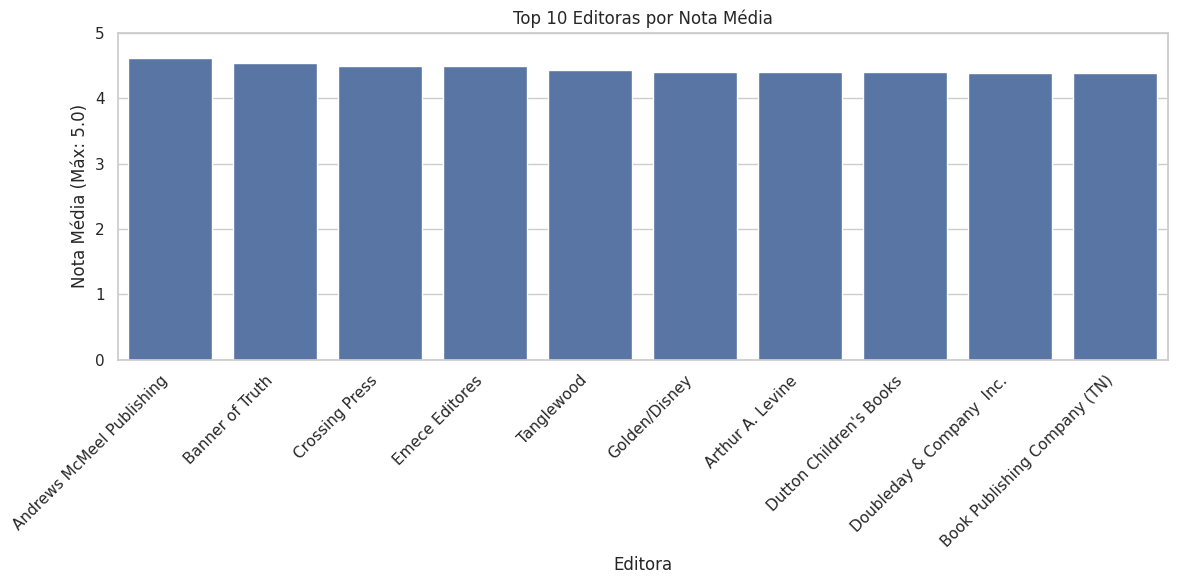

In [ ]:
plt.figure(figsize=(12, 6))
top_10_corte = df_pub_corte.head(10).copy()

top_10_corte['nota_media'] = top_10_corte['nota_media'].round(2)

sns.barplot(
    data=top_10_corte,
    x='editora',
    y='nota_media',
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Editoras por Nota Média')
plt.xlabel('Editora')
plt.ylabel('Nota Média (Máx: 5.0)')

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

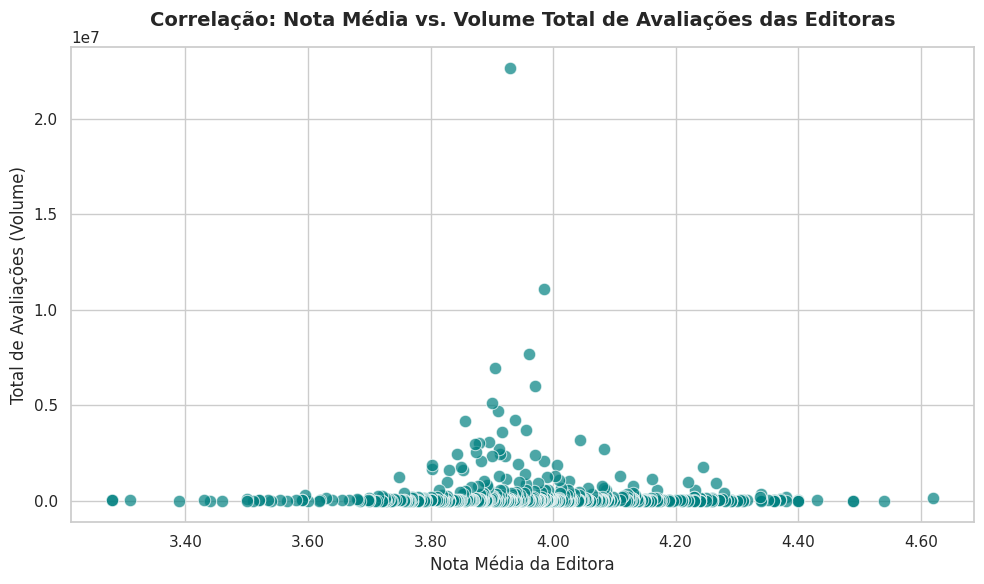

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_pub_corte,
    x='nota_media',
    y='total_av',
    alpha=0.7,
    color='teal',
    s=80
)

plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.title('Correlação: Nota Média vs. Volume Total de Avaliações das Editoras', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nota Média da Editora', fontsize=12)
plt.ylabel('Total de Avaliações (Volume)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_53365/2252811249.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


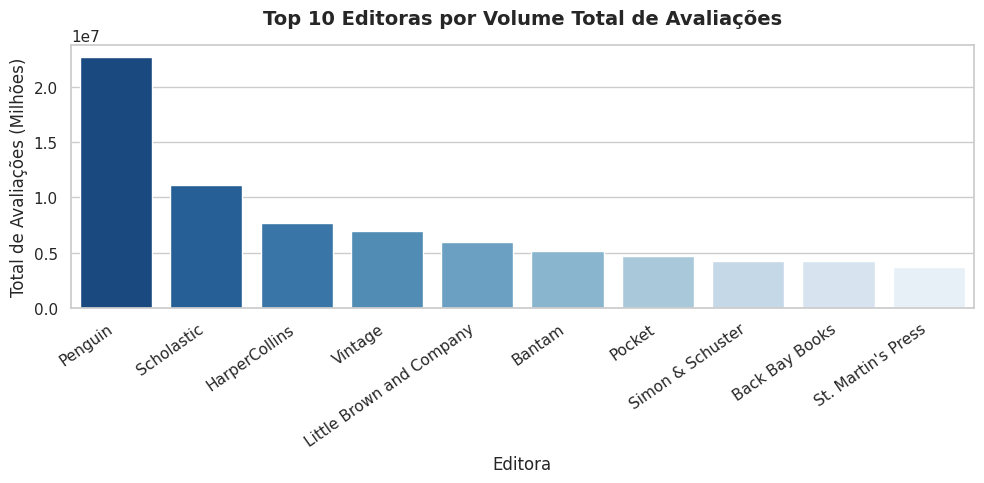

In [ ]:
plt.figure(figsize=(10, 5))
top_10_volume = df_pub_corte_media_total_av.sort_values(by='total_av', ascending=False).head(10)

sns.barplot(
    data=top_10_volume,
    x='editora',
    y='total_av',
    palette='Blues_r'
)
plt.xticks(rotation = 35, ha = 'right')

plt.title('Top 10 Editoras por Volume Total de Avaliações', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Editora', fontsize=12)
plt.ylabel('Total de Avaliações (Milhões)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_53365/85127772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


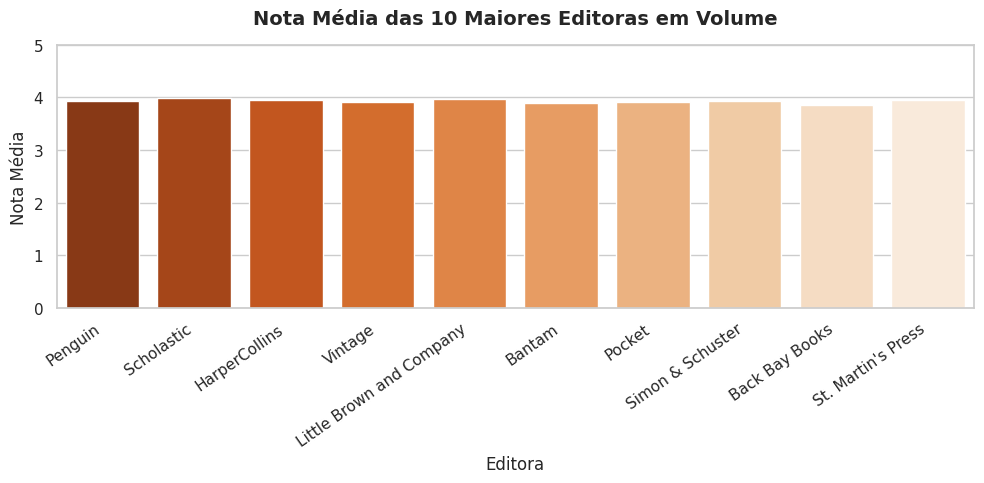

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_10_volume,
    x='editora',
    y='nota_media',
    palette='Oranges_r'
)

plt.xticks(rotation=35, ha='right')
plt.title('Nota Média das 10 Maiores Editoras em Volume', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Editora', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

##As três tabelas mostram como o número de avaliações pode criar dúvida nos resultados. Analisando o top 10 das editoras levando em conta primeiro a nota média, nenhuma editora aparece no corte por total de avaliações e vice e versa.
##Pra analisar isso, vamos verificar as top 3 editoras dos dois lados e ver o melhor livro de cada uma.

In [ ]:
top_3_nota = df_pub_corte.head(3)['editora'].tolist()
dados_df_corte_nota = []

for editora in top_3_nota:
    livros_editora = df_relevancia[df_relevancia['publisher'] == editora]
    if not livros_editora.empty:
        melhor_livro = livros_editora.sort_values(by='ratings_count', ascending=False).iloc[0]
        dados_df_corte_nota.append({
            'Editora': editora,
            'Título': melhor_livro['title'],
            'Autor': melhor_livro['authors'],
            'Nota Média': melhor_livro['average_rating'],
            'Total de Avaliações': melhor_livro['ratings_count']
        })

tabela_melhores_corte = pd.DataFrame(dados_df_corte_nota)

top_3_media_total = df_pub_corte_media_total_av.head(3)['editora'].tolist()
dados_df_volume = []

for editora in top_3_media_total:
    livros_editora = df_relevancia[df_relevancia['publisher'] == editora]
    if not livros_editora.empty:
        # Pega o livro com a maior nota média daquela editora
        melhor_livro = livros_editora.sort_values(by='ratings_count', ascending=False).iloc[0]
        dados_df_volume.append({
            'Editora': editora,
            'Título': melhor_livro['title'],
            'Autor': melhor_livro['authors'],
            'Nota Média': melhor_livro['average_rating'],
            'Total de Avaliações': melhor_livro['ratings_count']
        })

tabela_melhores_volume = pd.DataFrame(dados_df_volume)
print("=" * 100)
print('Best-Seller de cada editora por volume de avaliações da editora:')
display(tabela_melhores_volume)
print("=" * 100)
print('Best-Seller de cada editora por nota média da editora:')
display(tabela_melhores_corte)

Best-Seller de cada editora por volume de avaliações da editora:


,Editora,Título,Autor,Nota Média,Total de Avaliações
0,Penguin,Lord of the Flies,William Golding,3.68,2036679
1,Scholastic,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,2339585
2,HarperCollins,The Alchemist,Paulo Coelho/Alan R. Clarke/Özdemir İnce,3.86,1631221


Best-Seller de cada editora por nota média da editora:


,Editora,Título,Autor,Nota Média,Total de Avaliações
0,Andrews McMeel Publishing,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,4.63,49122
1,Banner of Truth,The Valley of Vision: A Collection of Puritan ...,Arthur Bennett,4.54,9476
2,Crossing Press,Sister Outsider: Essays and Speeches,Audre Lorde,4.49,12105


##E então encontramos provas de que a nota média é um conceito importante, desde que considerado em conjunto com o total de avaliações. Os livros tiveram quase 1 ponto de diferença entre os casos, já o volume de avaliações do grupo de maior sucesso é mais de 100 vezes superior ao menor número. Não há como comparar um livro com mais de 2 milhões de avaliações com um livro contendo apenas 10 mil.
#Então a variável editora pode sim fazer diferença no sucesso de um livro por expor esse conteúdo a número maior de pessoas.